# 4.2 Calidad y Limpieza de Datos

In [ ]:
import pandas as pd
raw = pd.read_csv("../Datos/Raw/raw_accidentes.csv", parse_dates=["TW"])

C:\Users\Sara\AppData\Local\Temp\ipykernel_27284\1132253762.py:2: DtypeWarning: Columns (3,19) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv("../Datos/Raw/raw_accidentes.csv", parse_dates=["TW"])


In [27]:
raw.describe()

,Lon,Lat,OBJECTID,PERIODO,Mes,Dia,Hora_num,TW
count,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000,125122
mean,-75.577059,6.250224,628445.870686,2017.999169,6.665063,15.623735,13.262728,2018-07-06 09:11:47.357618688
min,-75.701661,6.166846,503352.000000,2017.000000,1.000000,1.000000,0.000000,2017-01-01 00:00:00
25%,-75.586578,6.231896,537442.250000,2017.000000,4.000000,8.000000,9.000000,2017-09-25 16:00:00
50%,-75.574821,6.250107,665085.500000,2018.000000,7.000000,16.000000,14.000000,2018-07-04 16:30:00
75%,-75.565207,6.271176,720792.750000,2019.000000,10.000000,23.000000,17.000000,2019-04-17 10:00:00
max,-75.480742,6.368394,758669.000000,2019.000000,12.000000,31.000000,23.000000,2019-12-31 23:00:00
std,0.019038,0.028559,91283.479422,0.823582,3.404394,8.745684,5.241392,NaN


In [28]:
info_calidad = pd.DataFrame({
    'Tipo de Dato': raw.dtypes,
    'Valores Nulos': raw.isnull().sum(),
    'Porcentaje Nulos (%)': (raw.isnull().sum() / len(raw)) * 100
})

# Ordenar de mayor a menor porcentaje de nulos para ver qué columnas están más vacías
info_calidad = info_calidad.sort_values(by='Porcentaje Nulos (%)', ascending=False)
print(info_calidad)

                 Tipo de Dato  Valores Nulos  Porcentaje Nulos (%)
MES_NOMBRE             object          82740             66.127460
DISENO                 object            429              0.342865
RADICADO               object              5              0.003996
Lon                   float64              0              0.000000
GRAVEDAD               object              0              0.000000
Hora_num                int64              0              0.000000
FECHA                  object              0              0.000000
Dia                     int64              0              0.000000
Mes                     int64              0              0.000000
COMUNA                 object              0              0.000000
BARRIO                 object              0              0.000000
TIPO_GEOCOD            object              0              0.000000
Lat                   float64              0              0.000000
CBML                   object              0              0.00

In [29]:
raw.head(5)

,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,NaN,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,NaN,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,NaN,16,2017-07-02 16:00:00
3,-75.583062,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,1105,Malla vial,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,NaN,18,2017-03-29 18:00:00
4,-75.590193,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,1115,Malla vial,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,NaN,20,2017-07-26 20:00:00


In [31]:
# Eliminar la columna
raw = raw.drop(columns=['MES_NOMBRE'])

In [32]:
total_duplicados_id = raw.duplicated(subset=['OBJECTID']).sum()
print(f"Cantidad de OBJECTID duplicados: {total_duplicados_id}")

Cantidad de OBJECTID duplicados: 0


In [33]:
# Lista de columnas categóricas que realmente están en el DataFrame
columnas_validas = [col for col in ['CLASE', 'GRAVEDAD', 'DISENO', 'Dia_sem', 'BARRIO, COMUNA'] if col in raw.columns]

# 1. Ver el listado y frecuencias de los datos categóricos
for col in columnas_validas:
    print(f"\n--- Valores únicos y frecuencias en: {col} ---")
    print(raw[col].value_counts(dropna=False))

print("\n" + "="*50 + "\n")

# 2. Validar consistencia de horas (esta sí debe funcionar perfectamente)
horas_invalidas = raw[(raw['Hora_num'] < 0) | (raw['Hora_num'] > 23)]
print(f"Filas con horas fuera de rango (0-23): {len(horas_invalidas)}")

# 3. Validar la distribución de años (PERIODO)
print("\nDistribución de accidentes por año (PERIODO):")
print(raw['PERIODO'].value_counts())


--- Valores únicos y frecuencias en: CLASE ---


CLASE
Choque                86065
Otro                  12947
Atropello             11199
Caida Ocupante        10532
Volcamiento            4342
Incendio                 19
Caída Ocupante           14
Choque                    3
Choque y Atropello        1
Name: count, dtype: int64

--- Valores únicos y frecuencias en: GRAVEDAD ---
GRAVEDAD
HERIDO         60162
SOLO DAÑOS     52747
Con heridos     6552
Solo daños      4938
MUERTO           665
Con muertos       58
Name: count, dtype: int64

--- Valores únicos y frecuencias en: DISENO ---
DISENO
Tramo de via     76819
Interseccion     23944
Lote o Predio    17420
Glorieta          3870
Paso Elevado       905
Puente             629
Ciclo Ruta         511
Paso Inferior      433
NaN                429
Paso a Nivel        86
Tunel               36
Via peatonal        21
Pontón              19
Name: count, dtype: int64

--- Valores únicos y frecuencias en: Dia_sem ---
Dia_sem
VIERNES      20141
MARTES       19727
MIERCOLES    19005
JUEVES 

In [34]:
# 1. Limpiar espacios invisibles (stripping) y pasar todo a mayúsculas
raw['CLASE'] = raw['CLASE'].astype(str).str.strip().str.upper()
raw['GRAVEDAD'] = raw['GRAVEDAD'].astype(str).str.strip().str.upper()

# 2. Homologar los criterios de GRAVEDAD (reemplazar las variantes)
mapeo_gravedad = {
    'CON HERIDOS': 'HERIDO',
    'SOLO DAÑOS': 'SOLO DAÑOS', # Asegura que se mantenga el formato estándar
    'CON MUERTOS': 'MUERTO'
}
raw['GRAVEDAD'] = raw['GRAVEDAD'].replace(mapeo_gravedad)

# 3. Homologar las variantes en CLASE (quitar la tilde para unificar)
mapeo_clase = {
    'CAÍDA OCUPANTE': 'CAIDA OCUPANTE'
}
raw['CLASE'] = raw['CLASE'].replace(mapeo_clase)

In [35]:
print("--- CLASE Limpia ---")
print(raw['CLASE'].value_counts())

print("\n--- GRAVEDAD Limpia ---")
print(raw['GRAVEDAD'].value_counts())

--- CLASE Limpia ---
CLASE
CHOQUE                86068
OTRO                  12947
ATROPELLO             11199
CAIDA OCUPANTE        10546
VOLCAMIENTO            4342
INCENDIO                 19
CHOQUE Y ATROPELLO        1
Name: count, dtype: int64

--- GRAVEDAD Limpia ---
GRAVEDAD
HERIDO        66714
SOLO DAÑOS    57685
MUERTO          723
Name: count, dtype: int64


In [36]:
# Configurar Pandas para que no ponga límite al número de columnas mostradas
pd.set_option('display.max_columns', None)

# Mostrar los primeros 5 registros con todas sus columnas
raw.head(5)

,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,CAIDA OCUPANTE,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,CHOQUE,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,CHOQUE,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,16,2017-07-02 16:00:00
3,-75.583062,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,CHOQUE,CL 33 Norte CR 65,CL 033 065 000 00000,1105,Malla vial,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,18,2017-03-29 18:00:00
4,-75.590193,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,ATROPELLO,CL 50 CR 74,CL 050 074 000 00000,1115,Malla vial,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,20,2017-07-26 20:00:00


In [37]:
# Ver si la hora 0 o la hora 12 tienen un pico desproporcionado de accidentes
print("Top 5 de horas con más accidentes:")
print(raw['Hora_num'].value_counts().head(5))

Top 5 de horas con más accidentes:
Hora_num
17    9355
16    8321
15    7914
14    7799
12    7742
Name: count, dtype: int64


In [38]:
print("\nAccidentes por día del mes:")
print(raw['Dia'].value_counts().sort_index())


Accidentes por día del mes:
Dia
1     4016
2     4286
3     4143
4     4193
5     4259
6     4212
7     3928
8     4059
9     4062
10    4099
11    4107
12    4282
13    4069
14    4049
15    4114
16    4407
17    4290
18    4239
19    3970
20    3961
21    4143
22    4268
23    4268
24    4122
25    4008
26    4181
27    4107
28    4095
29    3461
30    3506
31    2218
Name: count, dtype: int64


(Es normal que el 31 tenga cerca de la mitad de registros que los demás días, simplemente porque solo la mitad de los meses tienen 31 días. Si tiene 0 o un número extremadamente bajo, hay un problema).

In [40]:
# 1. Reconstruir la fecha real del calendario
fechas_reales = pd.to_datetime(
    pd.DataFrame({'year': raw['PERIODO'], 'month': raw['Mes'], 'day': raw['Dia']}), 
    errors='coerce'
)

# 2. Mapear el nombre del día real a español
mapa_dias_sin_tildes = {
    'Monday': 'LUNES', 'Tuesday': 'MARTES', 'Wednesday': 'MIERCOLES', 
    'Thursday': 'JUEVES', 'Friday': 'VIERNES', 'Saturday': 'SABADO', 'Sunday': 'DOMINGO'
}
# Creamos una columna temporal en el DataFrame para comparar fácilmente
raw['Dia_Sem_REAL'] = fechas_reales.dt.day_name().map(mapa_dias_sin_tildes)

# Asegurar que tu columna original esté limpia y en mayúsculas
raw['Dia_sem'] = raw['Dia_sem'].astype(str).str.strip().str.upper()

# 3. Filtrar para ver solo los que NO coinciden
ejemplos_error = raw[raw['Dia_sem'] != raw['Dia_Sem_REAL']]

# Mostrar columnas clave para analizar el desfase
columnas_interes = ['PERIODO', 'Mes', 'Dia', 'Dia_sem', 'Dia_Sem_REAL', 'CLASE', 'GRAVEDAD']
ejemplos_error[columnas_interes].head(10)

,PERIODO,Mes,Dia,Dia_sem,Dia_Sem_REAL,CLASE,GRAVEDAD


In [41]:
# Límites geográficos reales aproximados del Valle de Aburrá (Caldas hasta Barbosa)
lon_min, lon_max = -75.75, -75.35
lat_min, lat_max = 6.05, 6.45

coordenadas_locas = raw[
    (raw['Lon'] < lon_min) | (raw['Lon'] > lon_max) |
    (raw['Lat'] < lat_min) | (raw['Lat'] > lat_max)
]

print(f"Cantidad de accidentes fuera del Valle de Aburrá: {len(coordenadas_locas)}")

Cantidad de accidentes fuera del Valle de Aburrá: 0


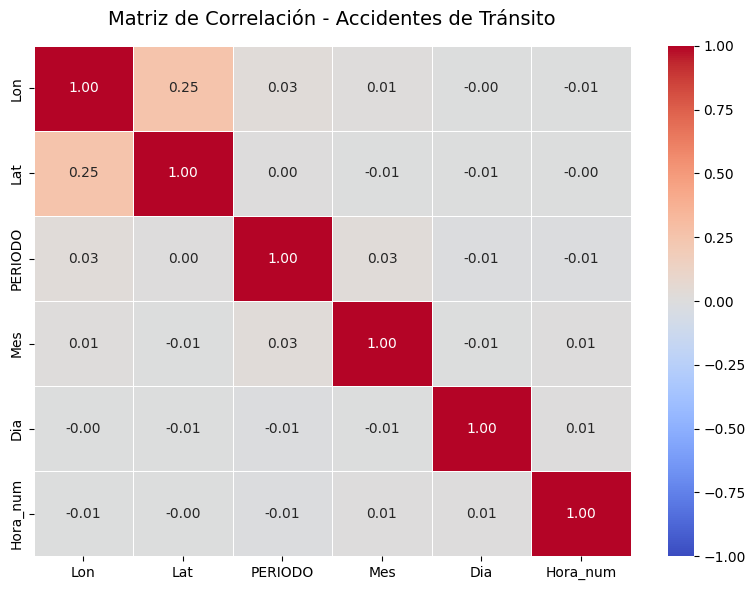

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar únicamente las columnas numéricas de tu dataset
columnas_numericas = ['Lon', 'Lat', 'PERIODO', 'Mes', 'Dia', 'Hora_num']
df_numerico = raw[columnas_numericas]

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df_numerico.corr()

# 3. Configurar el tamaño de la gráfica
plt.figure(figsize=(8, 6))

# 4. Crear el mapa de calor (Heatmap)
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra los números de la correlación dentro de cada cuadro
    cmap='coolwarm',     # Paleta de colores (azul para negativo, rojo para positivo)
    fmt=".2f",           # Limita los números a 2 decimales
    linewidths=0.5,      # Pone una línea delgada para separar los cuadros
    vmin=-1, vmax=1      # Forza a que la escala vaya de -1 a 1
)

# 5. Personalizar los títulos
plt.title('Matriz de Correlación - Accidentes de Tránsito', fontsize=14, pad=15)
plt.tight_layout()

# 6. Mostrar la gráfica
plt.show()

In [ ]:
import os

carpeta_staging = '../Datos/Staging/'

if not os.path.exists(carpeta_staging):
    os.makedirs(carpeta_staging)
    print(f"Carpeta '{carpeta_staging}' creada exitosamente.")

else:
    print(f"La carpeta '{carpeta_staging}' ya existe.")

ruta_archivo_final = os.path.join(carpeta_staging, 'accidentes_staging.csv')

raw.to_csv(ruta_archivo_final, index=False, encoding='utf-8')

print(f"¡Datos guardados exitosamente en: {ruta_archivo_final}!")

La carpeta '../Datos/Staging/' ya existe.
¡Datos guardados exitosamente en: ../Datos/Staging/accidentes_staging.csv!
¡Datos guardados exitosamente en: ../Datos/Staging/accidentes_staging.csv!
